#Bank_loan Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings 
import plotly.express as px

In [2]:
data = pd.read_csv(r"C:\Users\Dell\Downloads\datajupter\financial_loan.csv")

In [3]:
data["issue_date"]= pd.to_datetime(data["issue_date"], errors= "coerce")

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  object        
 2   application_type       38576 non-null  object        
 3   emp_length             38576 non-null  object        
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  object        
 6   home_ownership         38576 non-null  object        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  object        
 9   last_payment_date      38576 non-null  object        
 10  loan_status            38576 non-null  object        
 11  next_payment_date      38576 non-null  object        
 12  member_id              38576 non-null  int64         
 13  p

##Total_Loan Application


In [5]:
total_loan_application = data["id"].count()
print("total_loan_application:", total_loan_application)

total_loan_application: 38576


##Total loan fund

In [6]:
total_loan_amount = data["loan_amount"].sum()
total_loan_amount_millions = total_loan_amount/1000000
print(f"total amount:${total_loan_amount_millions:.2f}M")

total amount:$435.76M


##total Amount Received

In [7]:
total_amount = data["total_payment"].sum()
total_amount_received = total_amount/1000000
print(f"total amount Received: ${total_amount_received:.2f}M")

total amount Received: $473.07M


##Averge Interst Rate

In [10]:
interest_rate = data["int_rate"].mean()*100
print(f"Average intrest rate:{interest_rate:.2f}")

Average intrest rate:12.05


###Average_debt

In [9]:
Average_debt = data["dti"].mean()*100
print(f"Average_dti:{Average_debt:.2f}%")

Average_dti:13.33%


##Good loan Metrics

In [8]:
good_loans = data[data["loan_status"].isin(["Fully Paid","Current"])]
total_loan_applications = data["id"].count()
good_loan_applications = good_loans["id"].count()
good_loan_funded_amount = good_loans["loan_amount"].sum()
good_loan_received = good_loans["total_payment"].sum()
good_loans_funded_millions = good_loan_funded_amount/1000000
good_loans_received_millions = good_loan_received/1000000
print("good_loans_applications:", good_loan_applications)
print(f"good_loans_funded_amount:${good_loans_funded_millions:.2f}M")
print(f"good_loans_received_amount:${good_loans_received_millions:.2f}M")


good_loans_applications: 33243
good_loans_funded_amount:$370.22M
good_loans_received_amount:$435.79M


#Bad loan Metrics

In [10]:
bad_loans = data[data["loan_status"].isin(["Charged Off"])]
total_loan_applications = data["id"].count()
bad_loan_applications = bad_loans["id"].count()
bad_loan_funded_amount = bad_loans["loan_amount"].sum()
bad_loan_received = bad_loans["total_payment"].sum()
bad_loans_funded_millions = bad_loan_funded_amount/1000000
bad_loans_received_millions = bad_loan_received/1000000
print("bad_loans_applications:", bad_loan_applications)
print(f"bad_loans_funded_amount:${bad_loans_funded_millions:.2f}M")
print(f"bad_loans_received_amount:${bad_loans_received_millions:.2f}M")


bad_loans_applications: 5333
bad_loans_funded_amount:$65.53M
bad_loans_received_amount:$37.28M


##Monthly Trends Issue date for total funded Amount

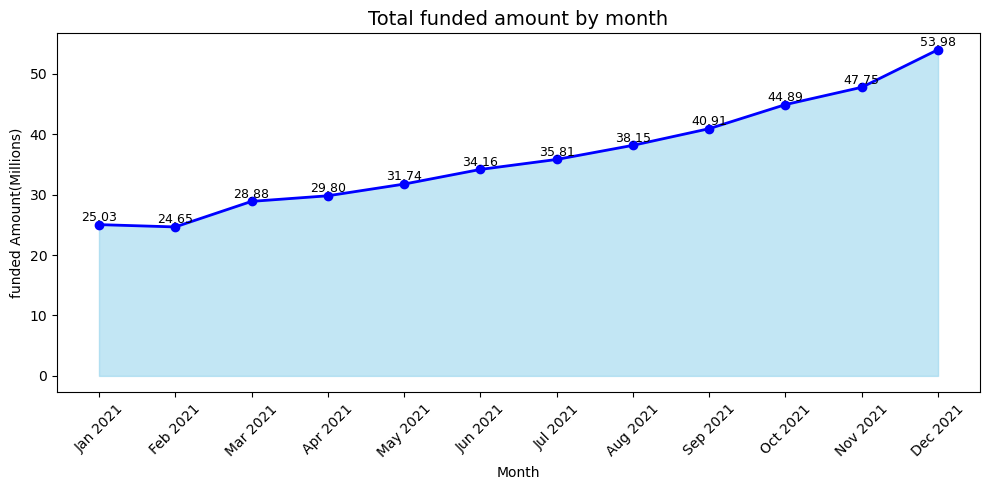

In [31]:
Monthly_funded = (data.sort_values("issue_date").assign(month_name =lambda x: x["issue_date"].dt.strftime("%b %Y")).groupby("month_name",sort=False)["loan_amount"]
           .sum().div(1000000).reset_index(name="loan_amount_millions"))

plt.figure(figsize=(10,5))
plt.fill_between(Monthly_funded["month_name"], Monthly_funded["loan_amount_millions"],color="skyblue", alpha=.5)
plt.plot(Monthly_funded["month_name"], Monthly_funded["loan_amount_millions"], color="blue", marker="o", linewidth=2)

for i, row in Monthly_funded.iterrows():
  plt.text(i, row["loan_amount_millions"]+ .1, f"{row["loan_amount_millions"]:.2f}",
          ha= "center", va= "bottom", fontsize=9, rotation=0, color="black")

plt.title("Total funded amount by month",fontsize=14)
plt.xlabel("Month")
plt.ylabel("funded Amount(Millions)")
plt.xticks(ticks=range(len(Monthly_funded)),labels=Monthly_funded["month_name"], rotation=45)
plt.grid(True,linestyle="--", alpha=.6)
plt.tight_layout()
plt.grid(False)
plt.show()

            

##Monthly Trends by Issue date for total Amount Received#

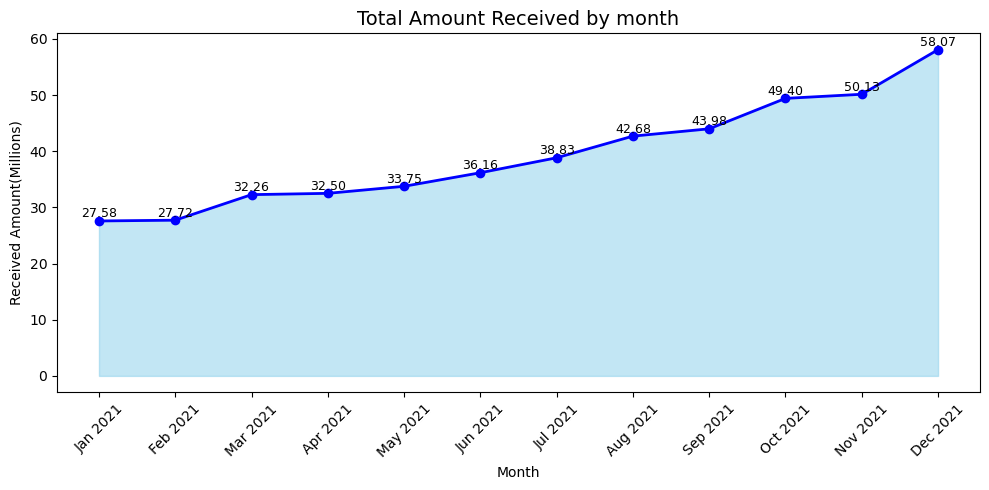

In [34]:
Monthly_Received = (data.sort_values("issue_date").assign(month_name =lambda x: x["issue_date"].dt.strftime("%b %Y")).groupby("month_name",sort=False)["total_payment"]
           .sum().div(1000000).reset_index(name="total_payment_millions"))

plt.figure(figsize=(10,5))
plt.fill_between(Monthly_Received["month_name"], Monthly_Received["total_payment_millions"],color="skyblue", alpha=.5)
plt.plot(Monthly_Received["month_name"], Monthly_Received["total_payment_millions"], color="blue", marker="o", linewidth=2)

for i, row in Monthly_Received.iterrows():
  plt.text(i, row["total_payment_millions"]+ .1, f"{row["total_payment_millions"]:.2f}",
          ha= "center", va= "bottom", fontsize=9, rotation=0, color="black")

plt.title("Total Amount Received by month",fontsize=14)
plt.xlabel("Month")
plt.ylabel("Received Amount(Millions)")
plt.xticks(ticks=range(len(Monthly_funded)),labels=Monthly_Received["month_name"], rotation=45)
plt.grid(True,linestyle="--", alpha=.6)
plt.tight_layout()
plt.grid(False)
plt.show()

##Monthly Trends by Issue date for total Amount Received#